In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
from sqlalchemy import create_engine

In [4]:
from dotenv import load_dotenv

In [5]:
import os

In [6]:
load_dotenv()
print("everything look goog on paper")

everything look goog on paper


In [7]:
engine = create_engine(
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

df = pd.read_sql("SELECT * FROM data_collection_spotprice ORDER BY start_date", engine)
print(df.shape)
df.head()

(35494, 5)


,id,start_date,end_date,price_eur_mwh,volume_mw
0,97,2024-01-01 00:00:00+01:00,2024-01-01 00:15:00+01:00,0.10,0.0
1,98,2024-01-01 01:00:00+01:00,2024-01-01 01:15:00+01:00,0.01,0.0
2,99,2024-01-01 02:00:00+01:00,2024-01-01 02:15:00+01:00,0.00,0.0
3,100,2024-01-01 03:00:00+01:00,2024-01-01 03:15:00+01:00,-0.01,0.0
4,101,2024-01-01 04:00:00+01:00,2024-01-01 04:15:00+01:00,-0.03,0.0


In [8]:
df.describe()

,id,price_eur_mwh,volume_mw
count,35494.000000,35494.000000,35494.000000
mean,17747.500000,61.425894,55.224928
std,10246.379564,45.269289,1062.613580
min,1.000000,-478.800000,0.000000
25%,8874.250000,23.000000,0.000000
50%,17747.500000,63.710000,0.000000
75%,26620.750000,93.000000,0.000000
max,35494.000000,473.280000,23159.400000


In [9]:
df['start_date'] = pd.to_datetime(df['start_date'],utc=True)

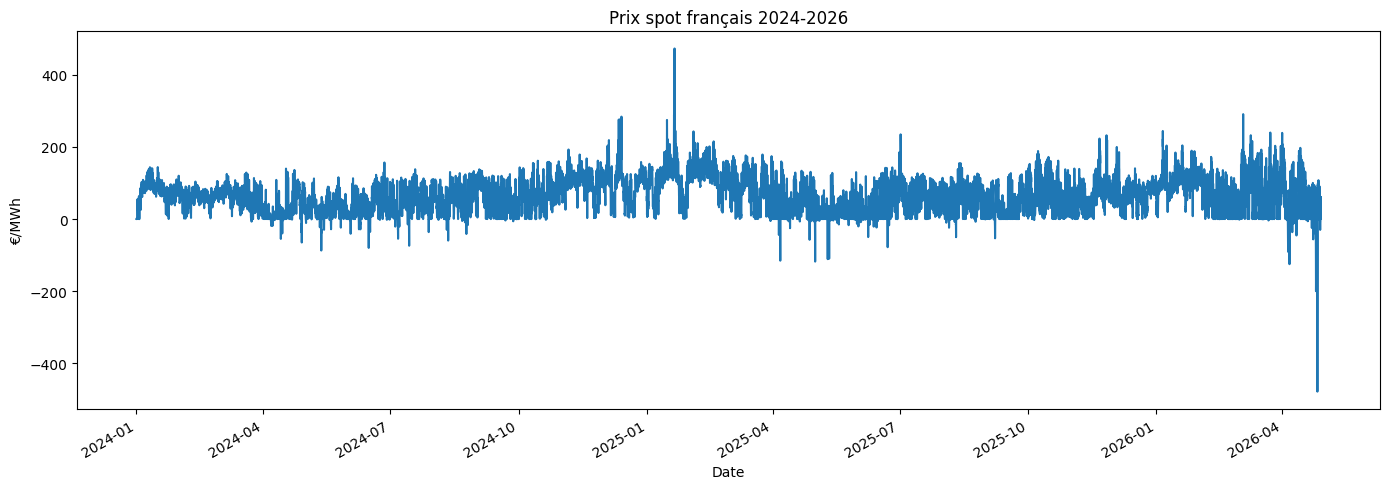

In [10]:
df['start_date'] = pd.to_datetime(df['start_date'], utc=True)
df.set_index('start_date', inplace=True)

df['price_eur_mwh'].plot(figsize=(14, 5), title='Prix spot français 2024-2026')
plt.xlabel('Date')
plt.ylabel('€/MWh')
plt.tight_layout()
plt.show()

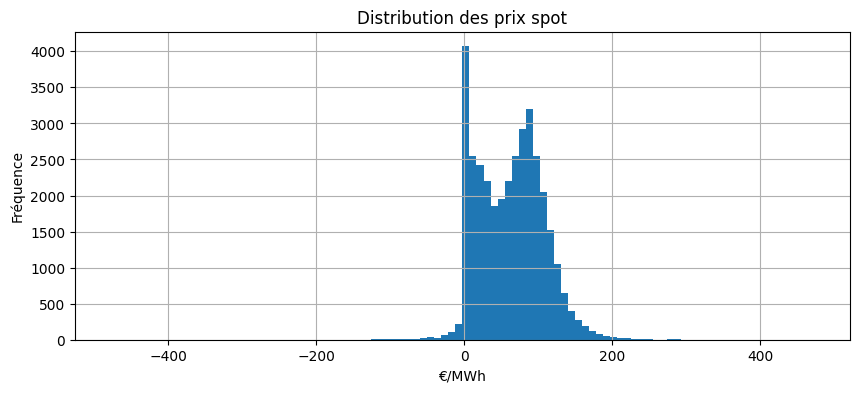

In [11]:
df['price_eur_mwh'].hist(bins=100, figsize=(10, 4))
plt.title('Distribution des prix spot')
plt.xlabel('€/MWh')
plt.ylabel('Fréquence')
plt.show()

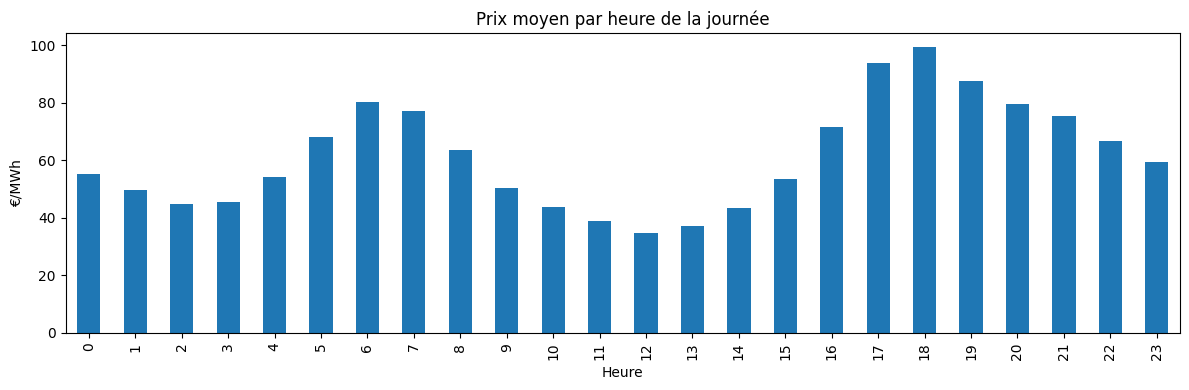

In [12]:
df['hour'] = df.index.hour
df.groupby('hour')['price_eur_mwh'].mean().plot(
    kind='bar', figsize=(12, 4), 
    title='Prix moyen par heure de la journée'
)
plt.xlabel('Heure')
plt.ylabel('€/MWh')
plt.tight_layout()
plt.show()


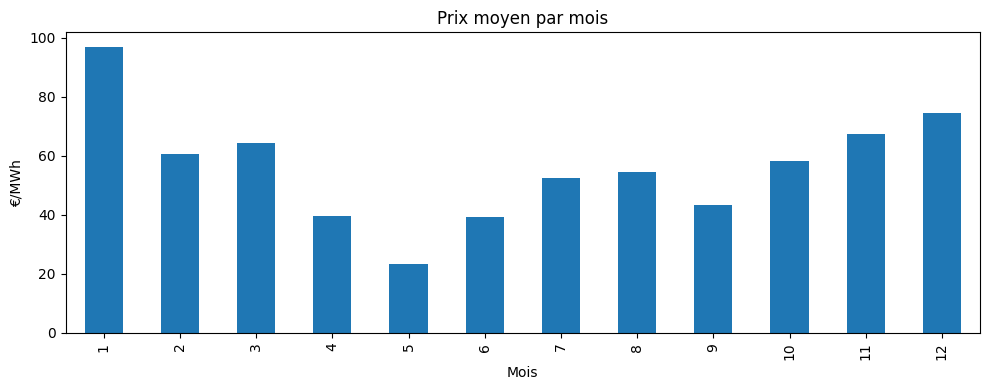

In [13]:
df['month'] = df.index.month
df.groupby('month')['price_eur_mwh'].mean().plot(
    kind='bar', figsize=(10, 4),
    title='Prix moyen par mois'
)
plt.xlabel('Mois')
plt.ylabel('€/MWh')
plt.tight_layout()
plt.show()

In [14]:
from statsmodels.tsa.stattools import adfuller
'''

'''
result = adfuller(df['price_eur_mwh'].dropna())
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")
print(f"Valeurs critiques: {result[4]}")

ADF Statistic: -12.8073
p-value: 0.0000
Valeurs critiques: {'1%': np.float64(-3.4305345308608586), '5%': np.float64(-2.8616215581123425), '10%': np.float64(-2.5668134108143543)}
